In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import spacy
import glob
from constants import BASE_PATH
import json
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import text_cleaning as tc
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import itertools
from analysis_utils import *

In [3]:
tqdm.pandas()

In [29]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [5]:
from constants import (
    JIBARO_WORDS, GIBARO_WORDS, CAMPESINO_WORDS, 
    LCCN_TO_NAME, BASE_PATH
)

In [6]:
nlp = spacy.blank("es")

# Load Data

In [7]:
# target_df = pd.read_pickle('prelim_analysis_target_records_df.pkl')

In [13]:
texts = []
cleaned_texts = []
for idx, r in target_df.iterrows():
    with open(f"{BASE_PATH}/{r['lccn']}/{r['year']}/{r['month']}/{r['day']}/{r['edition']}/{r['sequence']}/cleaned.json") as f:
        d = json.load(f)
        texts.append(list(zip(d['text_blocks_raw'], d['text_blocks_cleaned'])))

In [14]:
target_df['texts'] = texts
# One row per block
target_df = target_df.explode('texts')
target_df['text_raw'] = target_df['texts'].apply(lambda x: x[0]['text'])
target_df['text_cleaned'] = target_df['texts'].apply(lambda x: x[1]['text'])
target_df['text_id'] = target_df['texts'].apply(lambda x: x[0]['id'])
target_df['height'] = target_df['texts'].apply(lambda x: x[0]['height'])
target_df['width'] = target_df['texts'].apply(lambda x: x[0]['width'])
target_df['hpos'] = target_df['texts'].apply(lambda x: x[0]['hpos'])
target_df['vpos'] = target_df['texts'].apply(lambda x: x[0]['vpos'])
target_df['doc_cleaned'] = target_df['text_cleaned'].apply(lambda x: nlp(x))

In [15]:
target_df['contains_search_word_jibar'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, JIBARO_WORDS))
target_df['contains_search_word_gibar'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, GIBARO_WORDS))
target_df['contains_search_word_campesin'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, CAMPESINO_WORDS))


  0%|          | 0/1026296 [00:00<?, ?it/s]

  0%|          | 0/1026296 [00:00<?, ?it/s]

  0%|          | 0/1026296 [00:00<?, ?it/s]

In [16]:
target_df['surrounding_text_jibar'] = target_df['doc_cleaned'].progress_apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 20))

  0%|          | 0/1026296 [00:00<?, ?it/s]

# Exclude irrelevant instances

## Build Training Dataset

In [17]:
# jibar_docs_df = target_df.loc[target_df['contains_search_word_jibar']].reset_index().set_index(['link', 'text_id'])

In [46]:
# vectorizer = CountVectorizer(tokenizer=spacy_tokenizer, lowercase=False, ngram_range=(1, 2), min_df=5)
# tf_matrix = vectorizer.fit_transform(jibar_docs_df['doc_cleaned'].values).toarray()
# tf_matrix_surrounding = vectorizer.transform(jibar_docs_df['surrounding_text_jibar'])

/Users/weerasinghej/.local/share/virtualenvs/newspaper_ocr-SprSEqx4/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [47]:
tok_to_idx = {t: i for i, t in enumerate(vectorizer.get_feature_names_out())}

In [11]:
# labels_data_df = pd.read_pickle('jibaro_classification_labels_df.pkl')

In [66]:
labels_data = labels_data_df.to_dict('records')
processed_keys = set([(d['link'], d['text_id']) for d in labels_data])

In [ ]:
labels_data.append({
    'link': jibar_docs.index[i],
    'text_id': jibar_docs_df.iloc[i]['text_id'],
    'label': int(r)
})

In [74]:
idxs = np.argwhere(
    (tf_matrix[:, tok_to_idx['san']] > 0) & 
    (tf_matrix[:, tok_to_idx['jíbara']] > 0) 
)
to_label = [
    (jibar_docs_df.index[i][0], jibar_docs_df.index[i][1])
    for i in idxs.flatten()
]

In [80]:
for k in to_label:
    if k in processed_keys:
        continue
    print(k)
    print(jibar_docs_df.loc[k]['surrounding_text_jibar'])
    label = input("Label")
    if label == '-':
        continue
    labels_data.append({
        'link': k[0],
        'text_id': k[1],
        'label': int(label)
    })

In [478]:
# labels_data_df.to_pickle('jibaro_classification_labels_df.pkl')

In [451]:
idxs = [int(r[0]) for r in responses]
y = [int(r[1]) for r in responses]
X = tf_matrix[idxs,:]

jibar_docs_surrounding = jibar_docs.iloc[idxs].apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 40))
vectorizer2 = CountVectorizer(tokenizer=spacy_tokenizer, lowercase=False, ngram_range=(1, 2), min_df=2)
X2 = vectorizer2.fit_transform(jibar_docs_surrounding.values).toarray()

len(responses)


/Users/weerasinghej/.local/share/virtualenvs/newspaper_ocr-SprSEqx4/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


225

In [24]:
labels_data_df = pd.read_pickle('jibaro_classification_labels_df.pkl').set_index(['link', 'text_id'])

In [23]:
target_df = target_df.reset_index().set_index(['link', 'text_id'])

In [27]:
labels_data_df = pd.merge(labels_data_df, target_df, left_index=True, right_index=True)

In [28]:
labels_data_df

,,label,lccn,date,year,month,day,edition,sequence,total_tokens,title,...,campesino_freq,texts,text_raw,text_cleaned,height,width,hpos,vpos,doc_cleaned,surrounding_text_jibar
link,text_id,,,,,,,,,,,,,,,,,,,,,
https://chroniclingamerica.loc.gov/lccn/sn91099739/1876-02-16/ed-1/seq-3/,P3_TB00001,0,sn91099739,1876-02-16,1876,02,16,ed-1,seq-3,6481,Boletín mercantil de Puerto Rico,...,0.000000,"({'id': 'P3_TB00001', 'height': '26759', 'widt...","se encontraba en Flor del Cayo, acü- J\ndió se...","se encontraba en flor del cayo, acü- j\ndió se...",26759,3298,1115,1531,"(se, encontraba, en, flor, del, cayo, ,, acü-,...","(1, \n, de, su, teniente, coronel, d., josé, p..."
https://chroniclingamerica.loc.gov/lccn/sn91099739/1878-05-03/ed-1/seq-4/,P4_TB00001,1,sn91099739,1878-05-03,1878,05,03,ed-1,seq-4,8331,Boletín mercantil de Puerto Rico,...,0.000000,"({'id': 'P4_TB00001', 'height': '15236', 'widt...",EirfiiSA II T&PQRIS ESniSLES.\nCORREOS DE LAS ...,eirfiisa ii t&pqris esnisles.\ncorreos de las ...,15236,2670,883,2414,"(eirfiisa, ii, t&pqris, esnisles, ., \n, corre...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1879-11-23/ed-1/seq-3/,P3_TB00008,0,sn91099739,1879-11-23,1879,11,23,ed-1,seq-3,9572,Boletín mercantil de Puerto Rico,...,0.000000,"({'id': 'P3_TB00008', 'height': '14500', 'widt...","seis hombres, hiriendo á uno de ellos y\nlogra...","seis hombres, hiriendo á uno de ellos y\nlogra...",14500,2731,8872,1450,"(seis, hombres, ,, hiriendo, á, uno, de, ellos...","(,, recibidas, por, \n, telégrafo, ,, un, indi..."
https://chroniclingamerica.loc.gov/lccn/sn91099739/1877-12-05/ed-1/seq-3/,P3_TB00007,0,sn91099739,1877-12-05,1877,12,05,ed-1,seq-3,8752,Boletín mercantil de Puerto Rico,...,0.000000,"({'id': 'P3_TB00007', 'height': '18501', 'widt...",L>s talleres de costura do Puerto\nPrincipe en...,l>s talleres de costura do puerto\nprincipe en...,18501,2604,6241,7857,"(l, >, s, talleres, de, costura, do, puerto, \...","(\n, las, noticias, de, estos, últimos, dias, ..."
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-05-09/ed-1/seq-4/,P4_TB00003,1,sn91099739,1880-05-09,1880,05,09,ed-1,seq-4,8652,Boletín mercantil de Puerto Rico,...,0.000000,"({'id': 'P4_TB00003', 'height': '18931', 'widt...",an iim nan-nutlt\nRUTA DEL VAPOR ESPASOL\nwßan...,an iim nan-nutlt\nruta del vapor espasol\nwßan...,18931,2863,7460,1162,"(an, iim, nan-nutlt, \n, ruta, del, vapor, esp...",()
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
https://chroniclingamerica.loc.gov/lccn/sn88073003/1919-03-14/ed-1/seq-1/,P1_TB00025,0,sn88073003,1919-03-14,1919,03,14,ed-1,seq-1,4633,El Imparcial,...,0.000216,"({'id': 'P1_TB00025', 'height': '9789', 'width...",San Juan se había engalanado\n|-omo una chiqui...,san juan se había engalanado\n|-omo una chiqui...,9789,2584,14504,16020,"(san, juan, se, había, engalanado, \n, |-omo, ...","(y, vieja, canción, de, sus, \n, ¡, amores, ,,..."
https://chroniclingamerica.loc.gov/lccn/sn88073003/1919-09-27/ed-1/seq-4/,P4_TB00016,1,sn88073003,1919-09-27,1919,09,27,ed-1,seq-4,4975,El Imparcial,...,0.000000,"({'id': 'P4_TB00016', 'height': '14391', 'widt...",ESPECTACULOS PARA HOY |\nCine Tres Banderas. “...,espectaculos para hoy |\ncine tres banderas. “...,14391,2552,14003,10304,"(espectaculos, para, hoy, |, \n, cine, tres, b...","(., \n, fox, trot, hindustan, ,, o., g., wa, \..."
https://chroniclingamerica.loc.gov/lccn/sn88073003/1921-06-24/ed-1/seq-4/,P4_TB00008,0,sn88073003,1921-06-24,1921,06,24,ed-1,seq-4,5519,El Imparcial,...,0.000181,"({'id': 'P4_TB00008', 'height': '7346', 'width...",SAN JUAN SE DIVIERTE I\nHoy han dado comienzo ...,san juan se divierte i\nhoy han dado comienzo ...,7346,2448,13209,12614,"(san, juan, se, divierte, i, \n, hoy, han, dad...","(alegres, tocatas, ., |, \n, -a, los, docela, ..."


## Build Model

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import LinearSVC
from sklearn.metrics import make_scorer, f1_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_validate

In [77]:

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_doc_cleaned', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2), 'doc_cleaned'),
        ('tfidf_surrounding', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2), 'surrounding_text_jibar')
    ],
    remainder='drop'
)

base_svm = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=20000
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        # ('svm', base_svm),
        ('calibrated_svm', calibrated_svm),
    ]
)

In [79]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(
    pipeline,
    # X=X,
    X=labels_data_df,
    y=labels_data_df['label'],
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

print({k: np.mean(v) for k, v in results.items() if k.startswith("test_")})

{'test_accuracy': np.float64(0.9466666666666667), 'test_precision': np.float64(0.992), 'test_recall': np.float64(0.9103333333333333), 'test_f1': np.float64(0.9488717237126117), 'test_roc_auc': np.float64(0.9696952380952382)}


In [80]:
pipeline.fit(labels_data_df, labels_data_df['label'])

,steps,"[('preprocessor', ...), ('calibrated_svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf_doc_cleaned', ...), ('tfidf_surrounding', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
pred_y = pipeline.predict_proba(labels_data_df)[:, 1]

(array([ 92.,  10.,   1.,   0.,   0.,   0.,   0.,   7.,   4., 111.]),
 array([0.02226766, 0.11942107, 0.21657448, 0.31372789, 0.4108813 ,
        0.50803471, 0.60518812, 0.70234153, 0.79949494, 0.89664835,
        0.99380177]),
 <BarContainer object of 10 artists>)

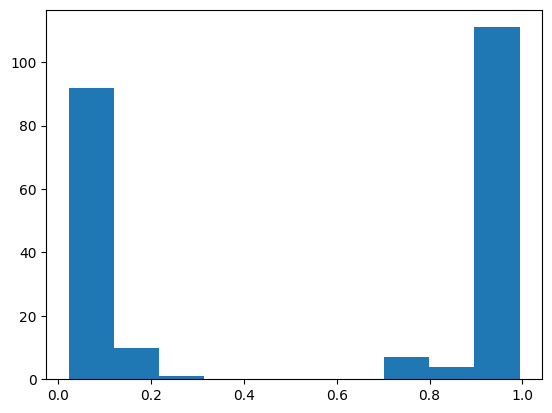

In [83]:
plt.hist(pred_y)

In [86]:
jibar_docs_df = target_df.loc[target_df['contains_search_word_jibar']]
len(jibar_docs_df)

2345

In [109]:
# Remove docs that classifier predicts as irrelevant
jibar_docs_df = jibar_docs_df.loc[pipeline.predict_proba(jibar_docs_df)[:, 1] < 0.2]

## Analyze

In [92]:
def get_term_freqs(docs):
    tf = defaultdict(int)
    for t in itertools.chain.from_iterable(docs):
        t = t.lower_
        # Remove spanish stop words and punctuation
        if t in nlp.Defaults.stop_words or t in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(t) < 2:
            continue
        tf[t] += 1
    return {'tf': dict(tf)}


In [110]:
tfs = get_term_freqs(jibar_docs_df['surrounding_text_jibar'])
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('jíbaro', 1036),
 ('jíbaros', 603),
 ('jibaro', 432),
 ('...', 301),
 ('don', 166),
 ('carrera', 115),
 ('año', 97),
 ('josé', 91),
 ('luis', 91),
 ('s.', 86),
 ('ii', 84),
 ('padre', 84),
 ('m.', 82),
 ('cayey', 81),
 ('j.', 81),
 ('maldición', 80),
 ('rey', 80),
 ('felipe', 79),
 ('caribe', 79),
 ('continente', 76),
 ('andrea', 76),
 ('andrés', 75),
 ('rico', 74),
 ('tempestad', 74),
 ('fué', 72),
 ('san', 70),
 ('mandada', 70),
 ('fray', 69),
 ('pobre', 68),
 ('sánchez', 68),
 ('martínez', 67),
 ('1582', 67),
 ('pueblo', 65),
 ('esfuerzo', 65),
 ('g.', 64),
 ('jibaros', 62),
 ('iñigo', 61),
 ('ocaña', 61),
 ('puerto', 58),
 ('pobres', 57),
 ('p.', 57),
 ('domínguez', 53),
 ('milla', 52),
 ('metros', 51),
 ('o.', 51),
 ('vida', 49),
 ('jíbara', 49),
 ('..', 49),
 ('barranquitas', 48),
 ('país', 48),
 ('señor', 47),
 ('isla', 44),
 ('do', 44),
 ('media', 44),
 ('premio', 43),
 ('baile', 43),
 ('caballos', 39),
 ('ramón', 39),
 ('tiempo', 38),
 ('campos', 37),
 ('ei', 35),
 ('juan', 

In [117]:
cv = CountVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2, ngram_range=(2, 4))
vec = cv.fit_transform(jibar_docs_df['surrounding_text_jibar']).toarray()

In [114]:
len(jibar_docs_df)

1707

In [119]:
sorted(bigram_tfs, key=lambda item: -item[1])

[('rey don', np.int64(80)),
 ('don felipe', np.int64(77)),
 ('felipe ii', np.int64(77)),
 ('padre caribe', np.int64(77)),
 ('rey don felipe', np.int64(77)),
 ('don felipe ii', np.int64(76)),
 ('ii año', np.int64(76)),
 ('rey don felipe ii', np.int64(76)),
 ('don felipe ii año', np.int64(74)),
 ('felipe ii año', np.int64(74)),
 ('andrea andrés', np.int64(72)),
 ('caribe continente', np.int64(71)),
 ('padre caribe continente', np.int64(70)),
 ('mandada rey', np.int64(69)),
 ('mandada rey don', np.int64(69)),
 ('año jíbaros', np.int64(68)),
 ('ii año jíbaros', np.int64(66)),
 ('luis sánchez', np.int64(66)),
 ('mandada rey don felipe', np.int64(66)),
 ('felipe ii año jíbaros', np.int64(64)),
 ('jíbaros josé', np.int64(64)),
 ('continente fray', np.int64(63)),
 ('año jíbaros josé', np.int64(62)),
 ('caribe continente fray', np.int64(62)),
 ('cayey esfuerzo', np.int64(62)),
 ('ii año jíbaros josé', np.int64(62)),
 ('padre caribe continente fray', np.int64(61)),
 ('esfuerzo andrea', np.int64(

In [118]:
bigram_tfs = zip(cv.get_feature_names_out(), vec.sum(axis=0))

In [107]:
bigram_tfs

In [96]:
cv.get_feature_names_out()

array(['abad jíbaro', 'abandonan montaña', 'abandonan montaña deber', ...,
       'ña cayey', 'ña cayey esfuerzo', 'ña cayey esfuerzo andrea'],
      shape=(1374,), dtype=object)

In [248]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import make_scorer, f1_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_validate

In [452]:

base_svm = LinearSVC(
    C=1.0,
    # class_weight="auto",
    random_state=42,
    max_iter=20000
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = cross_validate(
    calibrated_svm,
    # X=X,
    X=X2,
    y=y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

print({k: np.mean(v) for k, v in results.items() if k.startswith("test_")})

{'test_accuracy': np.float64(0.9022222222222223), 'test_precision': np.float64(0.910865105908584), 'test_recall': np.float64(0.9103333333333333), 'test_f1': np.float64(0.9102992345874521), 'test_roc_auc': np.float64(0.9477619047619047)}


In [446]:
np.mean(y)

np.float64(0.5466666666666666)

In [453]:
calibrated_svm.fit(X2, y)

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [454]:
pred_y = calibrated_svm.predict_proba(tf_matrix)[:, 1]

In [ ]:
np.argwhere((pred_y > 0.3) & (pred_y < 0.6)).flatten()

(array([67., 26., 10.,  0.,  0.,  0.,  2.,  5., 47., 68.]),
 array([3.00314445e-04, 9.98401943e-02, 1.99380074e-01, 2.98919954e-01,
        3.98459834e-01, 4.97999714e-01, 5.97539594e-01, 6.97079474e-01,
        7.96619354e-01, 8.96159234e-01, 9.95699113e-01]),
 <BarContainer object of 10 artists>)

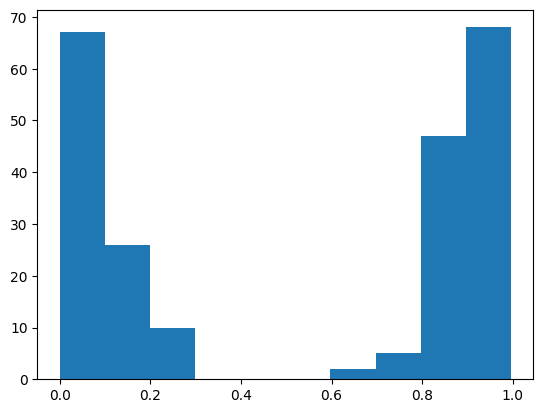

In [455]:
plt.hist(pred_y)

In [427]:
pos_idxs = np.argwhere(pred_y == 1).flatten()

In [428]:
jibar_docs[pred_y < 0.5]

link
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-2/    (creído, ver, algo, con, que, jamás, soñaron, ...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (cuando, creemos, que, nadie, había, \n, de, p...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (secunoart, io, esünwa, fsa, libe-at, que, com...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-27/ed-1/seq-3/    (Al, hacer, la, explosión, ,, un, jíbaro, que, ;)
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-29/ed-1/seq-3/    (Kpecia'ista, en, la, curación, de, \n, las, e...
                                                                                                   ...                        
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-5/    (|, \n, Girls, ,, Learm, Shorthand, ;, \n, |, ...
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-2/    (El, sol, era, un, derroche, 

In [316]:
len(responses)

167

In [429]:
len(jibar_docs)

2825

In [264]:
jibar_docs[pos_idxs]

/var/folders/nw/4k8cbbj93j9gvknkvl_w8c1c0000gq/T/ipykernel_57738/971559592.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  jibar_docs[pos_idxs]


Series([], Name: doc_cleaned, dtype: object)

In [68]:
def get_term_freqs(docs):
    tf = defaultdict(int)
    for t in itertools.chain.from_iterable(docs):
        t = t.lower_
        # Remove spanish stop words and punctuation
        if t in nlp.Defaults.stop_words or t in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(t) < 2:
            continue
        tf[t] += 1
    return {'tf': dict(tf)}


In [466]:
CountVectorizer(

In [467]:
len(selected_docs)

102

In [468]:
# tfs = get_term_freqs(selected_docs.apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 20)))
tfs = get_term_freqs(selected_docs)

In [469]:
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('jíbara', 59),
 ('jíbaro', 40),
 ('jibaro', 39),
 ('...', 39),
 ('fué', 28),
 ('jíbaros', 26),
 ('don', 24),
 ('san', 20),
 ('noche', 18),
 ('caballeros', 16),
 ('casa', 15),
 ('juan', 15),
 ('periódico', 13),
 ('do', 12),
 ('obra', 12),
 ('fiesta', 12),
 ('so', 11),
 ('ia', 11),
 ('ta', 11),
 ('damas', 11),
 ('colón', 11),
 ('bailes', 11),
 ('titulada', 11),
 ('campos', 11),
 ('rico', 10),
 ('cuba', 10),
 ('manuel', 10),
 ('trajes', 10),
 ('metros', 10),
 ('jibara', 10),
 ('eu', 9),
 ('corrientes', 9),
 ('celebrará', 9),
 ('consejo', 9),
 ('1543', 9),
 ('tradicional', 9),
 ('canciones', 9),
 ('obsequios', 9),
 ('apropiados', 9),
 ('ofrecerán', 9),
 ('con-', 9),
 ('currentes', 9),
 ('vestirán', 9),
 ('típicos', 9),
 ('ádeb', 9),
 ('pablo', 8),
 ('puerto', 8),
 ('ios', 8),
 ('amores', 8),
 ('sargento', 8),
 ('droz', 8),
 ('josé', 7),
 ('caballos', 7),
 ('cosa', 7),
 ('carrera', 7),
 ('cayey', 7),
 ('playa', 7),
 ('gui', 7),
 ('casado', 7),
 ('barrio', 6),
 ('fen', 6),
 ('recibe', 6),


In [ ]:
(jibar --> Gibar
